# Pengembangan Early Warning System (EWS) Kualitas Air
**Proyek Matakuliah MLOps, Web Service, dan Data Mining**

## 2. Exploratory Data Analysis - EDA (5%)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load Dataset
path = r"D:/ARFI/Kuliah/Project/project-semester4/Satria-Aqualculture/data/Recalculated_Aquaculture_Water_Suitability_Signals_WQI_Derived.csv"
dataset = pd.read_csv(path)
print(f'Shape: {dataset.shape}')
display(dataset.head())


Shape: (4300, 21)


,Record ID,Temperature,Turbidity (cm),Dissolved Oxygen (mg L-1),Biochemical Oxygen Demand (mg L-1),Carbon Dioxide (mg L-1),pH,Total Alkalinity (mg L-1 as CaCO3),Total Hardness (mg L-1 as CaCO3),Calcium (mg L-1),...,Ammonia (mg L-1),Nitrite (mg L-1),Phosphorus (mg L-1),Hydrogen Sulphide (mg L-1),Plankton Abundance (No. L-1),Water Quality Index (WQI),WQI-Derived Quality Label,WQI-Derived Quality Category,WQI-Derived Aquaculture Suitability Classification,WQI-Derived Aquaculture Suitability Description
0,1,31.200,13.535,0.222,6.393,8.077,6.703,240.671,645.052,152.765,...,0.929,0.094,0.200,0.040,2190,54.10,3,Poor/Marginal,Restricted / Stressed,Reduced Suitability: Water is significantly im...
1,2,31.066,42.971,3.475,7.121,9.950,6.457,281.103,710.607,164.371,...,0.644,0.072,0.200,0.027,558,74.81,2,Good/Marginal,Suitable,Standard Suitability: Water is generally safe ...
2,3,31.090,41.791,3.764,7.541,3.201,8.220,242.452,601.083,140.578,...,1.963,0.099,0.200,0.040,2001,69.90,3,Poor/Marginal,Restricted / Stressed,Reduced Suitability: Water is significantly im...
3,4,15.241,10.005,3.339,6.615,9.187,6.714,275.743,132.707,8.577,...,1.828,0.086,0.391,0.028,804,69.16,3,Poor/Marginal,Restricted / Stressed,Reduced Suitability: Water is significantly im...
4,5,31.077,10.726,0.556,7.654,3.121,8.252,265.220,524.329,116.310,...,1.703,0.097,0.432,0.038,718,48.57,4,Very Poor/Unsuitable,Unsuitable / Critical,"Critical Risk: Water is heavily contaminated, ..."


In [2]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4300 entries, 0 to 4299
Data columns (total 21 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Record ID                                           4300 non-null   int64  
 1   Temperature                                         4300 non-null   float64
 2   Turbidity (cm)                                      4300 non-null   float64
 3   Dissolved Oxygen (mg L-1)                           4300 non-null   float64
 4   Biochemical Oxygen Demand (mg L-1)                  4300 non-null   float64
 5   Carbon Dioxide (mg L-1)                             4300 non-null   float64
 6   pH                                                  4300 non-null   float64
 7   Total Alkalinity (mg L-1 as CaCO3)                  4300 non-null   float64
 8   Total Hardness (mg L-1 as CaCO3)                    4300 non-null   float64
 9

In [3]:
print(f"Jumlah Missing value:\n{dataset.isna().sum()}")

Jumlah Missing value:
Record ID                                             0
Temperature                                           0
Turbidity (cm)                                        0
Dissolved Oxygen (mg L-1)                             0
Biochemical Oxygen Demand (mg L-1)                    0
Carbon Dioxide (mg L-1)                               0
pH                                                    0
Total Alkalinity (mg L-1 as CaCO3)                    0
Total Hardness (mg L-1 as CaCO3)                      0
Calcium (mg L-1)                                      0
Estimated Magnesium (mg L-1)                          0
Ammonia (mg L-1)                                      0
Nitrite (mg L-1)                                      0
Phosphorus (mg L-1)                                   0
Hydrogen Sulphide (mg L-1)                            0
Plankton Abundance (No. L-1)                          0
Water Quality Index (WQI)                             0
WQI-Derived Quality Label 

In [4]:
print(f"Jumlah Duplikat{dataset.duplicated().sum()}")

Jumlah Duplikat0


In [5]:
# ==============================================================================
# TAHAP 2.0 — INITIALIZATION & DATA PROFILING
# ==============================================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Pastikan nama variabel dataframe sesuai (ganti 'dataset' jika Anda menggunakan 'df')
df_eda = dataset.copy()

# Definisi nama kolom target asli dari Kaggle (sebelum PyCaret Setup)
target_col = 'WQI-Derived Aquaculture Suitability Classification'

# Filter kolom fitur lingkungan numerik mendasar untuk analisis korelasi & PCA
cols_to_drop = [
    'Record ID', 'Water Quality Index (WQI)', 'WQI-Derived Quality Label', 
    'WQI-Derived Quality Category', target_col, 'WQI-Derived Aquaculture Suitability Description'
]
features_numeric = [col for col in df_eda.columns if col not in cols_to_drop and pd.api.types.is_numeric_dtype(df_eda[col])]

print(f"[INFO] Total data yang dianalisis: {df_eda.shape[0]} baris, {df_eda.shape[1]} kolom.")
print(f"[INFO] Kolom Fitur Numerik yang digunakan: {features_numeric}")

# Set tema dasar seaborn untuk estetika visual
sns.set_theme(style="ticks")

[INFO] Total data yang dianalisis: 4300 baris, 21 kolom.
[INFO] Kolom Fitur Numerik yang digunakan: ['Temperature', 'Turbidity (cm)', 'Dissolved Oxygen (mg L-1)', 'Biochemical Oxygen Demand (mg L-1)', 'Carbon Dioxide (mg L-1)', 'pH', 'Total Alkalinity (mg L-1 as CaCO3)', 'Total Hardness (mg L-1 as CaCO3)', 'Calcium (mg L-1)', 'Estimated Magnesium (mg L-1)', 'Ammonia (mg L-1)', 'Nitrite (mg L-1)', 'Phosphorus (mg L-1)', 'Hydrogen Sulphide (mg L-1)', 'Plankton Abundance (No. L-1)']


--- Distribusi Target ---
Label Highly Suitable: 2800 sampel (65.12%)
Label Restricted / Stressed: 1291 sampel (30.02%)
Label Suitable: 192 sampel (4.47%)
Label Unsuitable / Critical: 17 sampel (0.40%)


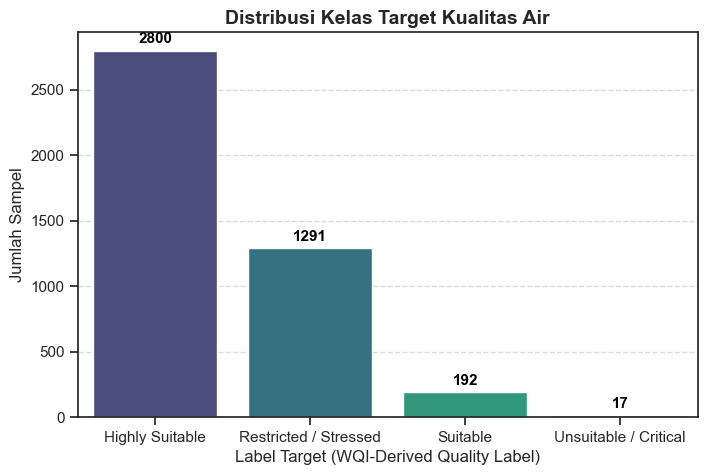

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# # Pastikan nama kolom sesuai dengan target Anda
# target_col = 'WQI-Derived Quality Label'

# 1. Menampilkan jumlah sampel dan persentase untuk masing-masing kelas
print("--- Distribusi Target ---")
class_counts = dataset[target_col].value_counts().sort_index()
class_percentages = dataset[target_col].value_counts(normalize=True).sort_index() * 100

for label, count in class_counts.items():
    perc = class_percentages[label]
    print(f"Label {label}: {count} sampel ({perc:.2f}%)")

# 2. Visualisasi Bar Chart
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=dataset, x=target_col, palette='viridis', order=class_counts.index)

# Menambahkan angka di atas bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=11, fontweight='bold', color='black', xytext=(0, 3), 
                textcoords='offset points')

plt.title('Distribusi Kelas Target Kualitas Air', fontsize=14, fontweight='bold')
plt.xlabel('Label Target (WQI-Derived Quality Label)', fontsize=12)
plt.ylabel('Jumlah Sampel', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


[INFO] Membangun Pairplot... Silakan tunggu beberapa saat.


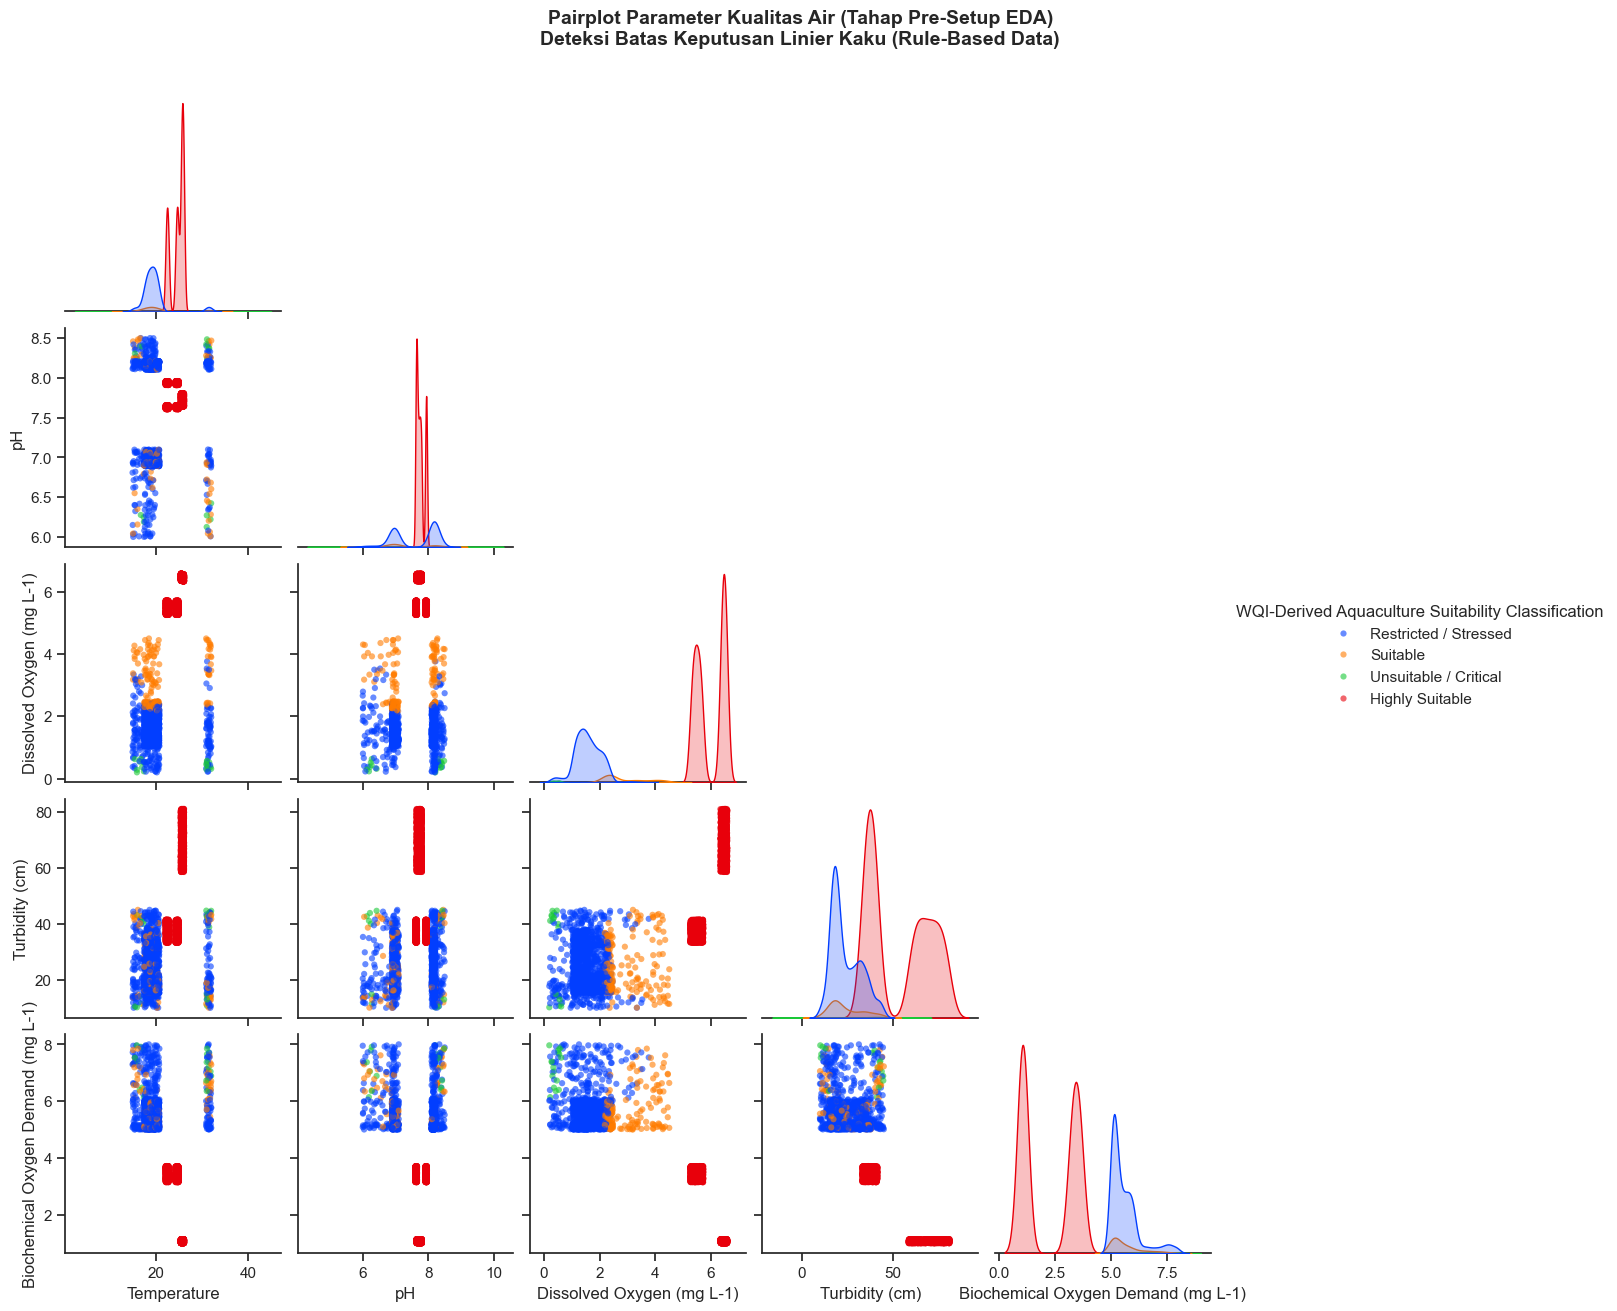

In [7]:
# ==============================================================================
# TAHAP 2.1 — MULTIVARIATE PAIRPLOT ANALYSIS
# ==============================================================================
print("[INFO] Membangun Pairplot... Silakan tunggu beberapa saat.")

# Memilih 5 fitur makro paling kritikal agar grafik tidak terlalu padat & berat
key_features = [
    'Temperature', 'pH', 'Dissolved Oxygen (mg L-1)', 
    'Turbidity (cm)', 'Biochemical Oxygen Demand (mg L-1)'
]

df_pairplot = df_eda[key_features + [target_col]].copy()

g = sns.pairplot(
    data=df_pairplot, 
    hue=target_col, 
    palette="bright", 
    corner=True,         # Menghilangkan duplikasi plot cermin di sisi kanan atas
    diag_kind="kde",     # Menampilkan distribusi kepadatan kontinu pada diagonal
    plot_kws={'alpha': 0.6, 'edgecolor': 'none', 's': 20}
)

g.fig.suptitle(
    "Pairplot Parameter Kualitas Air (Tahap Pre-Setup EDA)\nDeteksi Batas Keputusan Linier Kaku (Rule-Based Data)", 
    fontsize=14, fontweight='bold', y=1.05
)
plt.show()

In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4300 entries, 0 to 4299
Data columns (total 21 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Record ID                                           4300 non-null   int64  
 1   Temperature                                         4300 non-null   float64
 2   Turbidity (cm)                                      4300 non-null   float64
 3   Dissolved Oxygen (mg L-1)                           4300 non-null   float64
 4   Biochemical Oxygen Demand (mg L-1)                  4300 non-null   float64
 5   Carbon Dioxide (mg L-1)                             4300 non-null   float64
 6   pH                                                  4300 non-null   float64
 7   Total Alkalinity (mg L-1 as CaCO3)                  4300 non-null   float64
 8   Total Hardness (mg L-1 as CaCO3)                    4300 non-null   float64
 9

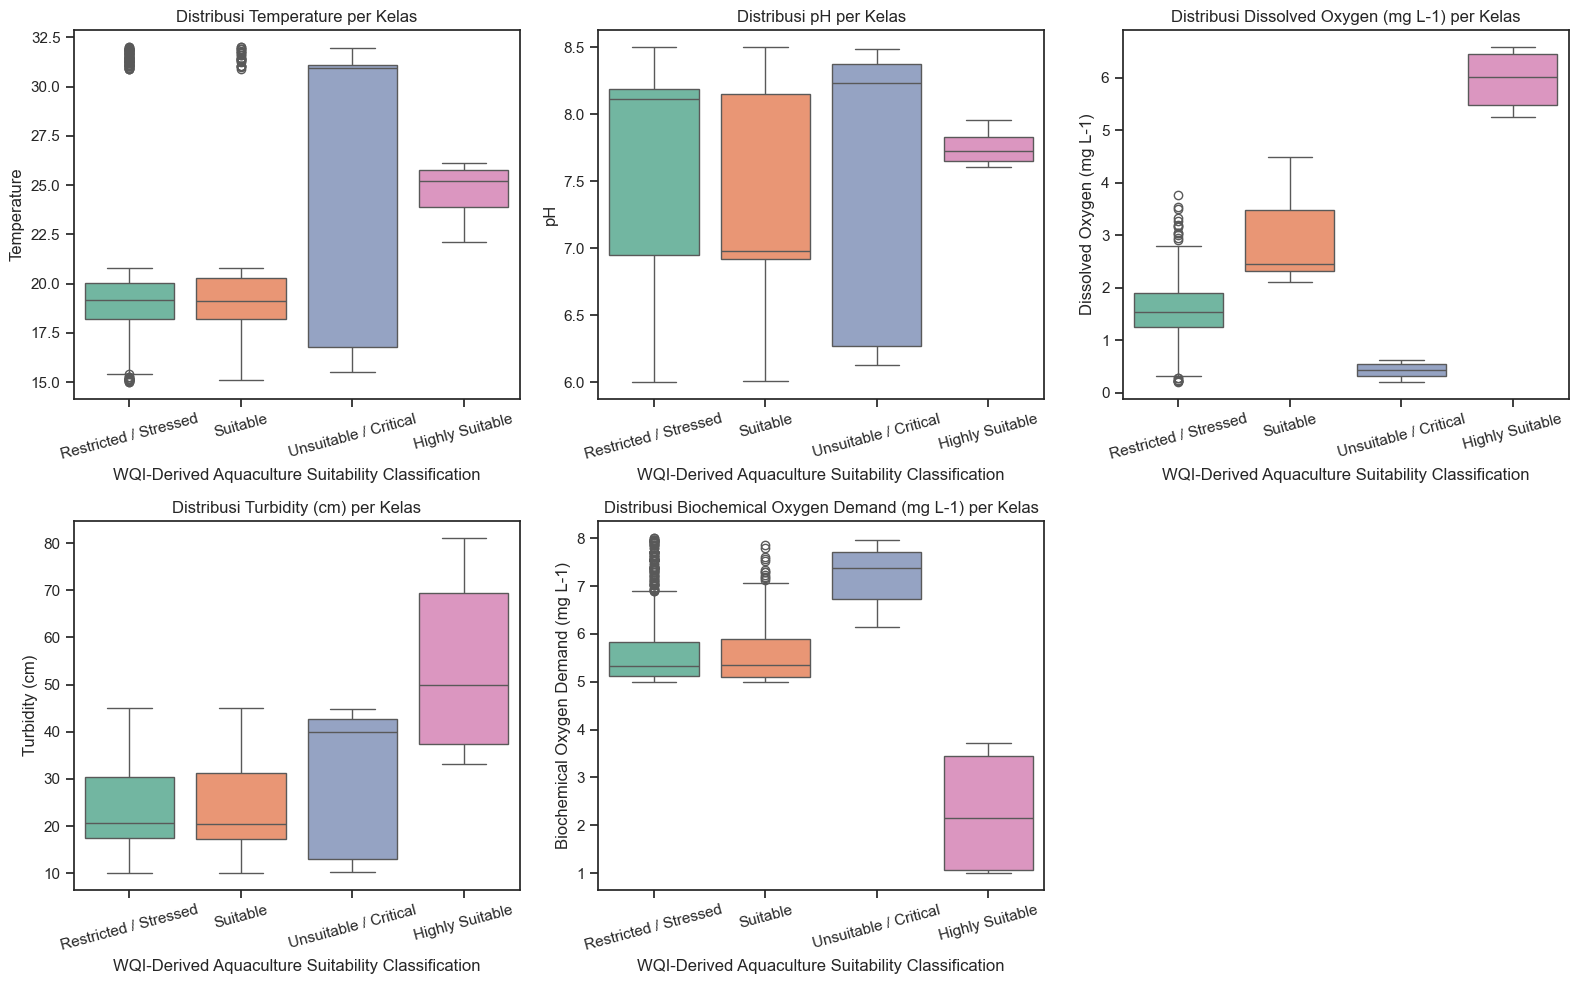

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt


# 1. Boxplot untuk melihat isolasi mutlak per-fitur
plt.figure(figsize=(16, 10))
for i, col in enumerate(key_features, 1):
    plt.subplot(2, 3, i)
    # Menggunakan boxplot untuk menekankan perbedaan dan distribusi antar kelas
    sns.boxplot(x=target_col, y=col, data=dataset, palette='Set2')
    plt.title(f'Distribusi {col} per Kelas')
    plt.xticks(rotation=15)

plt.tight_layout()
plt.show()


[INFO] Membuat Scatter Plot 2D (pH vs Temperature)...


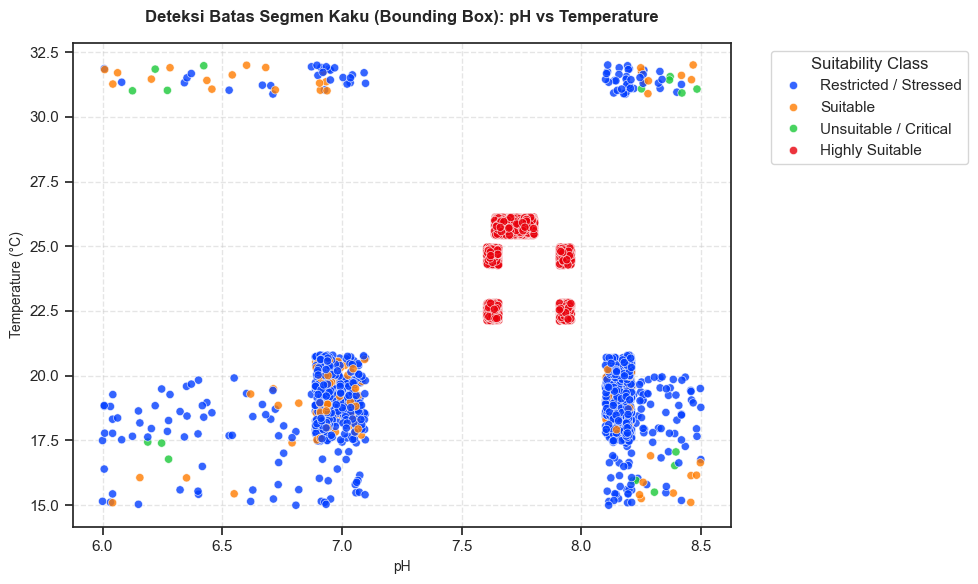

In [10]:
# ==============================================================================
# TAHAP 2.2 — DETAILED INTERACTION CHECK (ZOOM-IN BOUNDARY)
# ==============================================================================
print("[INFO] Membuat Scatter Plot 2D (pH vs Temperature)...")

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='pH', 
    y='Temperature', 
    hue=target_col, 
    data=df_eda, 
    palette='bright', 
    alpha=0.8,
    edgecolor='w',
    s=35
)

plt.title(
    'Deteksi Batas Segmen Kaku (Bounding Box): pH vs Temperature', 
    fontsize=12, fontweight='bold', pad=15
)
plt.xlabel('pH', fontsize=10)
plt.ylabel('Temperature (°C)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Suitability Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

[INFO] Menghitung Matriks Korelasi...


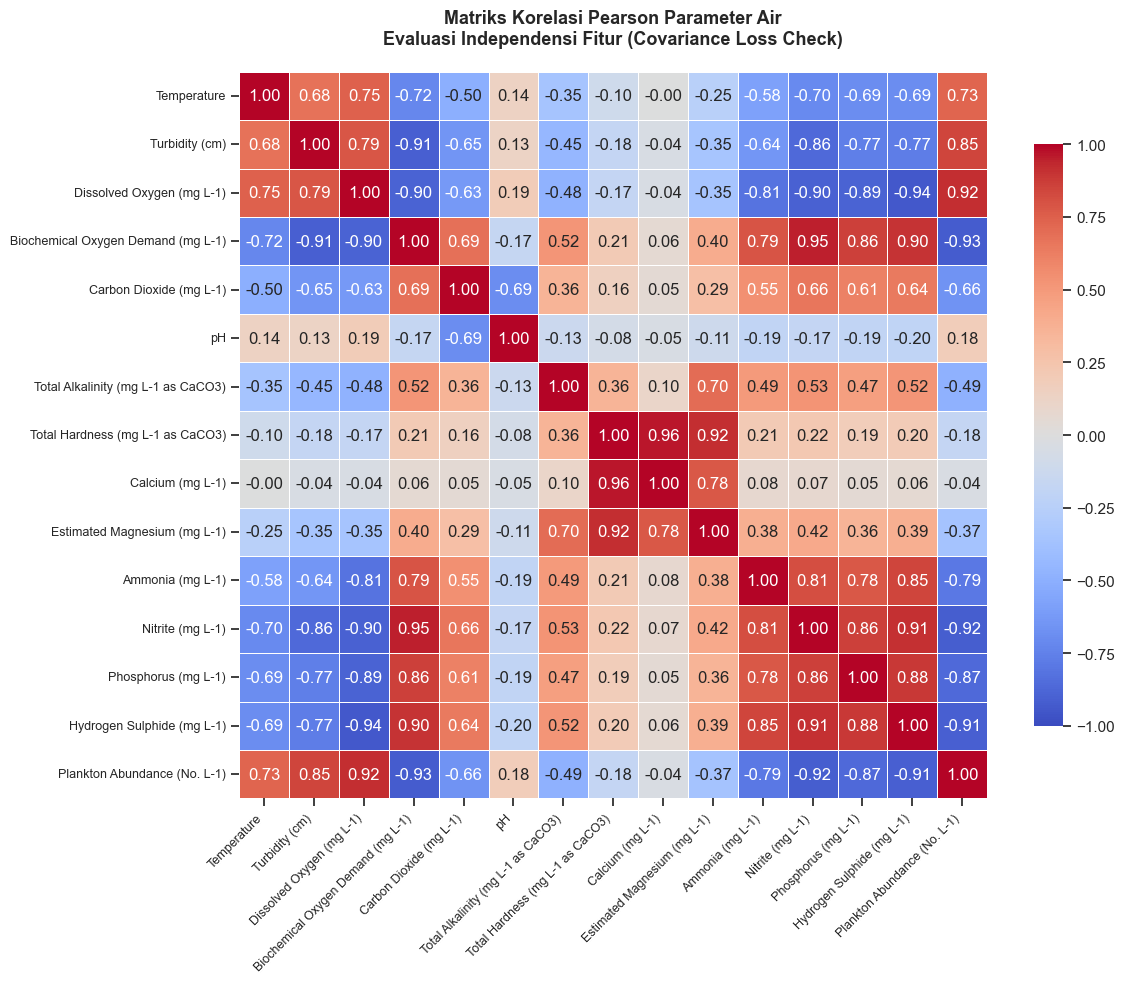

In [11]:
# ==============================================================================
# TAHAP 2.3 — LINEAR CORRELATION CHECK (HEATMAP)
# ==============================================================================
print("[INFO] Menghitung Matriks Korelasi...")

df_corr = df_eda[features_numeric].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    df_corr, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, vmax=1, 
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title(
    'Matriks Korelasi Pearson Parameter Air\nEvaluasi Independensi Fitur (Covariance Loss Check)', 
    fontsize=13, fontweight='bold', pad=20
)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

[INFO] Melakukan Ekstraksi Komponen Utama (PCA 2D Projection)...


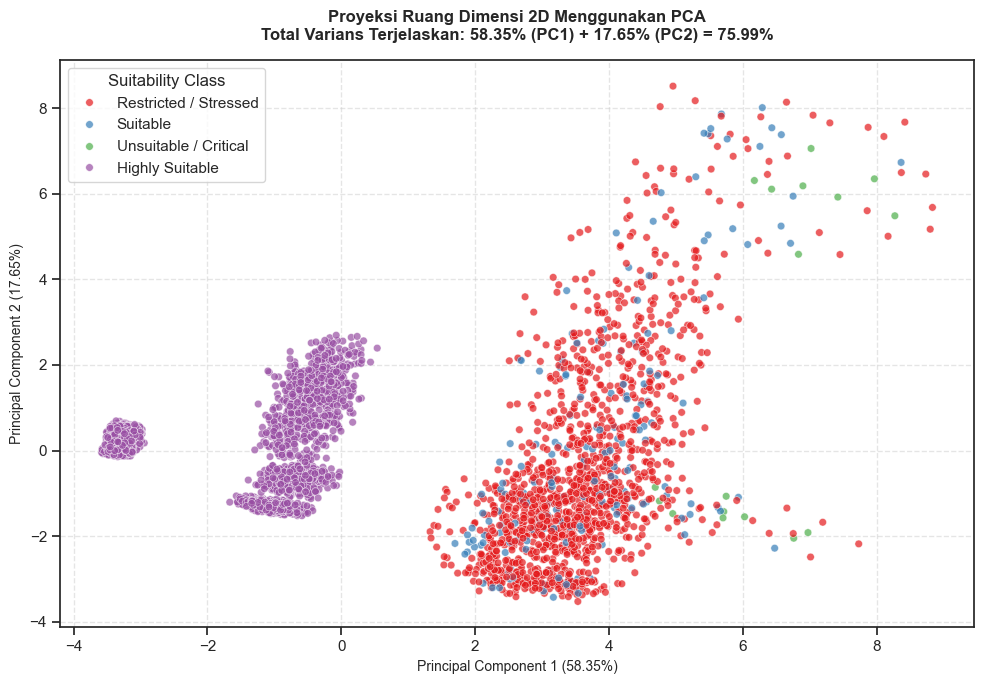

[INFO] Seluruh blok analisis EDA Selesai dijalankan.


In [12]:
# ==============================================================================
# TAHAP 2.4 — REDUCTION DIMENSIONALITY ANALYSIS (PCA 2D)
# ==============================================================================
print("[INFO] Melakukan Ekstraksi Komponen Utama (PCA 2D Projection)...")

# Standarisasi fitur lingkungan sebelum ekstraksi PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_eda[features_numeric])

# Transformasi ke 2 Komponen Utama (PCA)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Hitung persentase varians yang berhasil dijelaskan oleh model PCA
var_explained = pca.explained_variance_ratio_ * 100

# Bungkus ke dalam DataFrame baru untuk visualisasi
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Target'] = df_eda[target_col].values

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Target', 
    data=df_pca, 
    palette='Set1', 
    alpha=0.7,
    s=30
)

plt.title(
    f'Proyeksi Ruang Dimensi 2D Menggunakan PCA\nTotal Varians Terjelaskan: {var_explained[0]:.2f}% (PC1) + {var_explained[1]:.2f}% (PC2) = {sum(var_explained):.2f}%', 
    fontsize=12, fontweight='bold', pad=15
)
plt.xlabel(f'Principal Component 1 ({var_explained[0]:.2f}%)', fontsize=10)
plt.ylabel(f'Principal Component 2 ({var_explained[1]:.2f}%)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Suitability Class')
plt.tight_layout()
plt.show()

print("[INFO] Seluruh blok analisis EDA Selesai dijalankan.")

In [13]:
# from ydata_profiling import ProfileReport
# # 3. Generate Profile Report
# profile = ProfileReport(dataset, title="PBL EDA Report", explorative=True)

# # 4. Output Hasil
# # Pilihan A: Tampilkan langsung di Jupyter Notebook
# profile.to_notebook_iframe()

# # Pilihan B: Simpan sebagai file HTML 
# # profile.to_file("PBL_eda_report.html")

## 3. Data Preprocessing (20%)
Menghapus kolom deskripsi teks yang tidak digunakan, melakukan pembagian data Train/Test, dan menggunakan `RobustScaler` untuk menangani *outliers* yang terlihat pada EDA.

In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import RandomizedSearchCV, learning_curve, train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, recall_score, confusion_matrix, classification_report
from lightgbm import LGBMClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression




In [15]:
from mlflow import MlflowClient

# 1. Setup Tracking Server & Experiment Name
mlflow.set_tracking_uri('http://127.0.0.1:5000')

# Validasi dan pemulihan otomatis jika eksperimen berstatus 'deleted'
client = MlflowClient()
experiment_name = 'aq-water-quality-classification'
exp = client.get_experiment_by_name(experiment_name)

if exp and exp.lifecycle_stage == 'deleted':
    print(f"[MLflow] Mendeteksi eksperimen '{experiment_name}' dalam Trash. Memulihkan...")
    client.restore_experiment(exp.experiment_id)

# Sekarang aman untuk mengaktifkan eksperimen
mlflow.set_experiment(experiment_name)

# Target folder untuk Baked Model di runtime app
ARTIFACT_DIR = "../app/domains/water/artifacts/water_quality_pipeline"

In [16]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4300 entries, 0 to 4299
Data columns (total 21 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Record ID                                           4300 non-null   int64  
 1   Temperature                                         4300 non-null   float64
 2   Turbidity (cm)                                      4300 non-null   float64
 3   Dissolved Oxygen (mg L-1)                           4300 non-null   float64
 4   Biochemical Oxygen Demand (mg L-1)                  4300 non-null   float64
 5   Carbon Dioxide (mg L-1)                             4300 non-null   float64
 6   pH                                                  4300 non-null   float64
 7   Total Alkalinity (mg L-1 as CaCO3)                  4300 non-null   float64
 8   Total Hardness (mg L-1 as CaCO3)                    4300 non-null   float64
 9

In [17]:
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# 2. Inisialisasi Data 
# (Asumsi data sudah di-load ke variabel 'dataset' dari tahap sebelumnya)
df_clean = dataset.copy()

# 3. Definisi Target Baru (Sudah Numerik)
target_col = 'WQI-Derived Quality Label'

# 4. Sanitasi Kebocoran Data (Data Leakage)
# Semua turunan WQI selain target HARUS dibuang agar model benar-benar belajar dari fitur lingkungan
leakage_cols = [
    'Record ID', 
    'Water Quality Index (WQI)', 
    'WQI-Derived Quality Category', 
    'WQI-Derived Aquaculture Suitability Classification', # <--- Ini sekarang jadi leakage
    'WQI-Derived Aquaculture Suitability Description'
]

cols_to_drop = [col for col in leakage_cols if col in df_clean.columns]
df_clean = df_clean.drop(columns=cols_to_drop)

print(f"[INFO] Target disetel ke: {target_col}")
print(f"[INFO] Dimensi data setelah sanitasi leakage: {df_clean.shape}")




[INFO] Target disetel ke: WQI-Derived Quality Label
[INFO] Dimensi data setelah sanitasi leakage: (4300, 16)


In [ ]:
# ==============================================================================
# BLOK 2: DATA SPLITTING 
# ==============================================================================
# 1. Pemisahan Fitur (X) dan Target (y)
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

# 2. Train-Test Split (Berstrata)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"[INFO] Dimensi X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"[INFO] Distribusi Kelas Data Latih:\n{y_train.value_counts().sort_index()}")



[INFO] Dimensi X_train: (3440, 15) | X_test: (860, 15)
[INFO] Distribusi Kelas Data Latih:
WQI-Derived Quality Label
1    2240
2     153
3    1033
4      14
Name: count, dtype: int64


## 4. Baseline Model
Bagian ini menggunakan **MLflow** untuk melacak berbagai eksperimen *hyperparameter tuning* pada model Klasifikasi untuk memprediksi *Aquaculture Suitability Tier*.

In [19]:
# 3. Fungsi Utility: Learning Curve
def plot_learning_curve(pipeline, X_train_data, y_train_data, model_name):
    train_sizes, train_scores, test_scores = learning_curve(
        pipeline, X_train_data, y_train_data, cv=5, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='f1_macro'
    )
    plt.figure(figsize=(6, 4))
    plt.plot(train_sizes, np.mean(train_scores, axis=1), label="Training F1-Macro")
    plt.plot(train_sizes, np.mean(test_scores, axis=1), label="Cross-validation F1-Macro")
    plt.title(f"Learning Curve: {model_name}")
    plt.legend(loc="best")
    plt.grid(True)

In [20]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, recall_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
import mlflow
import matplotlib.pyplot as plt

# ==============================================================================
# BLOK 3: FASE 1 - BASELINE COMPARISON
# ==============================================================================

# 1. Kompensasi Class Imbalance
# Kalkulasi bobot penalti secara dinamis berdasarkan frekuensi inversi. 
# Wajib untuk model yang tidak mendukung input string 'balanced' secara native (seperti regresi logistik pada iterasi tertentu).
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

# 2. Inisialisasi Kandidat Model
# Parameter class_weight='balanced' disuntikkan secara eksplisit pada seluruh algoritma
# untuk memaksa fungsi kerugian (loss function) berfokus pada kelas minoritas (Unsuitable/Critical).
baseline_models = {
    "RandomForest": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "DecisionTree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced'),
    "LogisticRegression": LogisticRegression(random_state=42, max_iter=1000, class_weight=class_weight_dict)
}

best_model_name = None
best_f1_macro = 0  

print("--- Memulai Baseline Comparison ---")

# Pembersihan state MLflow untuk mencegah bentrokan sesi (zombie runs) dari eksekusi cell sebelumnya
if mlflow.active_run():
    mlflow.end_run()

with mlflow.start_run(run_name="Baseline_Comparison_Phase"):
    for name, model in baseline_models.items():
        # Penggunaan nested runs untuk memisahkan metrik dan artefak masing-masing algoritma di dasbor MLflow
        with mlflow.start_run(run_name=name, nested=True):
            
            # Isolasi proses scaling di dalam pipeline menjamin tidak ada kebocoran informasi distribusi data uji ke fase pelatihan
            pipeline = Pipeline([('scaler', RobustScaler()), ('classifier', model)])
            pipeline.fit(X_train, y_train)
            
            y_pred = pipeline.predict(X_test)
            y_prob = pipeline.predict_proba(X_test) 
            
            # 3. Ekstraksi Metrik Evaluasi
            acc = accuracy_score(y_test, y_pred)
            f1_weighted = f1_score(y_test, y_pred, average='weighted')
            # F1-Macro dikalkulasi sebagai acuan utama penyeleksian karena sifatnya yang kejam terhadap kesalahan prediksi minoritas
            f1_macro = f1_score(y_test, y_pred, average='macro') 
            roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovo', average='weighted')
            # Recall label [4] diekstrak secara spesifik untuk memonitor sensitivitas model pada kelas kolam paling kritis
            recall_critical = recall_score(y_test, y_pred, labels=[4], average=None)[0]
            
            # 4. Telemetri MLOps
            mlflow.log_param("model", name)
            mlflow.log_metrics({
                "accuracy": acc, 
                "f1_weighted": f1_weighted,
                "f1_macro": f1_macro, 
                "roc_auc": roc_auc, 
                "recall_critical": recall_critical
            })
            
            print(f"{name:<20} | F1-Macro: {f1_macro:.4f} | Acc: {acc:.4f} | Recall(Crit): {recall_critical:.4f}")

            # 5. Ekspor Visualisasi Audit
            plot_learning_curve(pipeline, X_train, y_train, name)
            fig = plt.gcf()
            mlflow.log_figure(fig, f"learning_curve_{name}.png")
            plt.close(fig)

            # 6. Seleksi Model Juara (Champion Selection)
            # Logika dikunci pada F1-Macro sesuai dengan batasan problem framing WQI yang timpang
            if f1_macro > best_f1_macro:
                best_f1_macro = f1_macro
                best_model_name = name

print(f"\n[HASIL] Model terpilih untuk Tuning berdasarkan F1-Macro: {best_model_name}")

--- Memulai Baseline Comparison ---


RandomForest         | F1-Macro: 0.8997 | Acc: 0.9849 | Recall(Crit): 0.6667
🏃 View run RandomForest at: http://127.0.0.1:5000/#/experiments/1/runs/78f9d6947d6f47bbb644b2ec464dbe5c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
DecisionTree         | F1-Macro: 0.9228 | Acc: 0.9860 | Recall(Crit): 1.0000
🏃 View run DecisionTree at: http://127.0.0.1:5000/#/experiments/1/runs/0b563c4fd95949a9b25b7bd872add86d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
LightGBM             | F1-Macro: 0.9783 | Acc: 0.9930 | Recall(Crit): 1.0000
🏃 View run LightGBM at: http://127.0.0.1:5000/#/experiments/1/runs/c1dd19cf09ef40c1a2dd8688c020ba40
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
LogisticRegression   | F1-Macro: 0.9032 | Acc: 0.9767 | Recall(Crit): 1.0000
🏃 View run LogisticRegression at: http://127.0.0.1:5000/#/experiments/1/runs/31c5463ca2fa44f7910fbe8b9b9bb07e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
🏃 View run Baseline_Comparison_Pha

## Tuning

In [21]:
from sklearn.base import clone
import seaborn as sns
import pandas as pd

# ==============================================================================
# BLOK 4: FASE 2 - TUNING, FINAL EVALUATION 
# ==============================================================================
print(f"--- Memulai Tahap Tuning Khusus untuk: {best_model_name} ---")

param_distributions = {
    'classifier__n_estimators': [100, 150, 200, 300],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__max_depth': [3, 5, 7, -1],
    'classifier__num_leaves': [15, 31, 63],
    'classifier__min_child_samples': [20, 30, 50],
    'classifier__subsample': [0.7, 0.8, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 1.0]
}

# PENYESUAIAN: Menggunakan clone() untuk mereset bobot latih model pemenang baseline
# Langkah ini menjamin proses RandomizedSearchCV berjalan dari state kosong secara adil.
fresh_classifier = clone(baseline_models[best_model_name])

tuning_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('classifier', fresh_classifier)
])

with mlflow.start_run(run_name=f"Tuning_Phase_{best_model_name}_champion"):
    # Parameter n_iter=50 dan cv=10 dikunci untuk memperluas cakupan ruang pencarian parameter
    search = RandomizedSearchCV(
        estimator=tuning_pipeline,
        param_distributions=param_distributions,
        n_iter=50,
        cv=10,
        scoring='f1_macro',
        n_jobs=-1,
        random_state=42
    )
    
    search.fit(X_train, y_train)
    best_pipeline = search.best_estimator_
    
    # 1. Inferensi Data Uji Bersih
    y_pred_tuned = best_pipeline.predict(X_test)
    y_prob_tuned = best_pipeline.predict_proba(X_test)
    
    # 2. Perhitungan Komprehensif Metrik Final
    final_acc = accuracy_score(y_test, y_pred_tuned)
    final_f1_weighted = f1_score(y_test, y_pred_tuned, average='weighted')
    final_f1_macro = f1_score(y_test, y_pred_tuned, average='macro')
    final_roc_auc = roc_auc_score(y_test, y_prob_tuned, multi_class='ovo', average='weighted')
    final_recall_critical = recall_score(y_test, y_pred_tuned, labels=[4], average=None)[0]
    
    # Telemetri Parameter dan Metrik ke MLflow Tracking Server
    mlflow.log_params(search.best_params_)
    mlflow.log_metrics({
        "final_accuracy": final_acc,
        "final_f1_weighted": final_f1_weighted,
        "final_f1_macro": final_f1_macro,
        "final_roc_auc": final_roc_auc,
        "final_recall_critical": final_recall_critical
    })
    
    print(f"Best Params: {search.best_params_}")
    print(f"F1-Macro: {final_f1_macro:.4f} | Accuracy: {final_acc:.4f} | Recall(Crit): {final_recall_critical:.4f}")
    
    # 3. Penyimpanan Artefak Grafis
    print("\n[INFO] Generating Artifacts...")
    plot_learning_curve(best_pipeline, X_train, y_train, f"Tuned_{best_model_name}")
    fig_lc = plt.gcf()
    mlflow.log_figure(fig_lc, f"artifacts/learning_curve_tuned_{best_model_name}.png")
    plt.close(fig_lc)
    
    # PENYESUAIAN: Ekstraksi target label secara dinamis dari y_test untuk mencegah misalignment urutan heatmap
    unique_labels = sorted(list(set(y_test)))
    cm = confusion_matrix(y_test, y_pred_tuned)
    
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=unique_labels, yticklabels=unique_labels)
    plt.title(f'Confusion Matrix: Tuned {best_model_name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    fig_cm = plt.gcf()
    mlflow.log_figure(fig_cm, "artifacts/confusion_matrix.png")
    plt.close(fig_cm)
    
    # Pembuatan laporan klasifikasi tekstual sebagai berkas rekam jejak analitis
    report = classification_report(y_test, y_pred_tuned)
    report_path = "classification_report.txt"
    with open(report_path, "w") as f:
        f.write(report)
    mlflow.log_artifact(report_path, "artifacts")
    
    # 4. REGISTRASI MODEL (Model Registry) DENGAN SIGNATURE CONTRACT
    # Inferensi otomatis menjamin kepatuhan tipe data API (input/output schema) saat ditarik oleh backend app/
    signature = infer_signature(X_train, best_pipeline.predict(X_train))
    input_example = X_train.iloc[:5]
    
    model_info = mlflow.sklearn.log_model(
        sk_model=best_pipeline,
        artifact_path="water_quality_pipeline",
        registered_model_name=f"EWS_{best_model_name}_champion",
        signature=signature,
        input_example=input_example
    )
    
    # Pembaruan alias ke model versi teranyar pada Model Registry Server
    from mlflow.tracking import MlflowClient
    client = MlflowClient()
    client.set_registered_model_alias(
        name=f"EWS_{best_model_name}_champion",
        alias="best-experiment",
        version=model_info.registered_model_version
    )
    print(f"[MLflow] Berhasil menetapkan alias untuk model versi {model_info.registered_model_version}")

print("\n[SUKSES] Seluruh alur MLOps selesai. Pipeline dengan Signature Contract telah terekam.")

--- Memulai Tahap Tuning Khusus untuk: LightGBM ---
Best Params: {'classifier__subsample': 0.7, 'classifier__num_leaves': 63, 'classifier__n_estimators': 200, 'classifier__min_child_samples': 30, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.7}
F1-Macro: 0.9349 | Accuracy: 0.9895 | Recall(Crit): 1.0000

[INFO] Generating Artifacts...


2026/05/31 23:33:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/31 23:33:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Registered model 'EWS_LightGBM_champion' already exists. Creating a new version of this model...
2026/05/31 23:34:01 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: EWS_LightGBM_champion, version 2
Created version '2' of model 'EWS_LightGBM_champion'.


[MLflow] Berhasil menetapkan alias untuk model versi 2
🏃 View run Tuning_Phase_LightGBM_champion at: http://127.0.0.1:5000/#/experiments/1/runs/e17e1144faef4b94bc735ef99904b3fd
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1

[SUKSES] Seluruh alur MLOps selesai. Pipeline dengan Signature Contract telah terekam.


[INFO] Mengalkulasi SHAP values untuk model pemenang (LightGBM)...


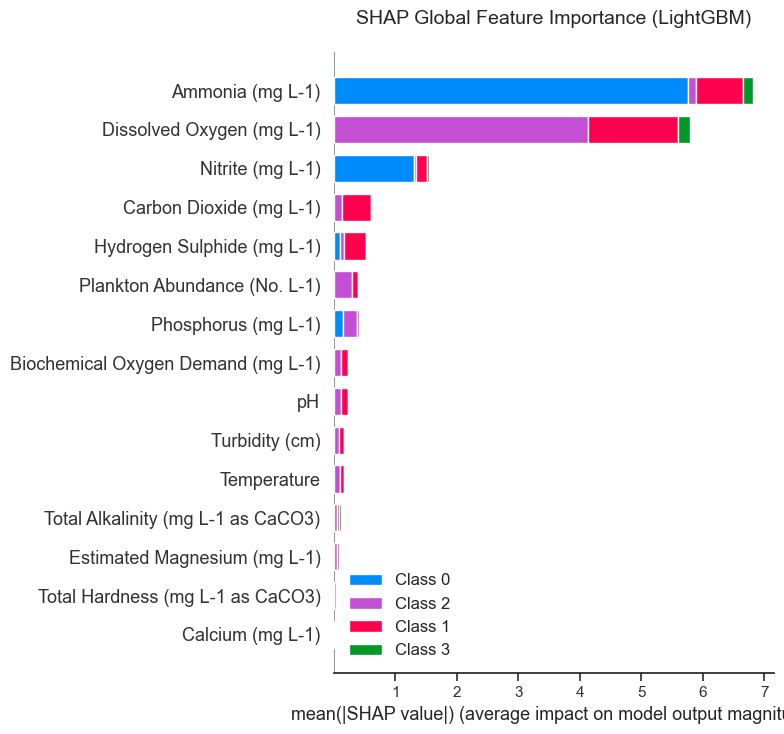

<Figure size 1200x600 with 0 Axes>

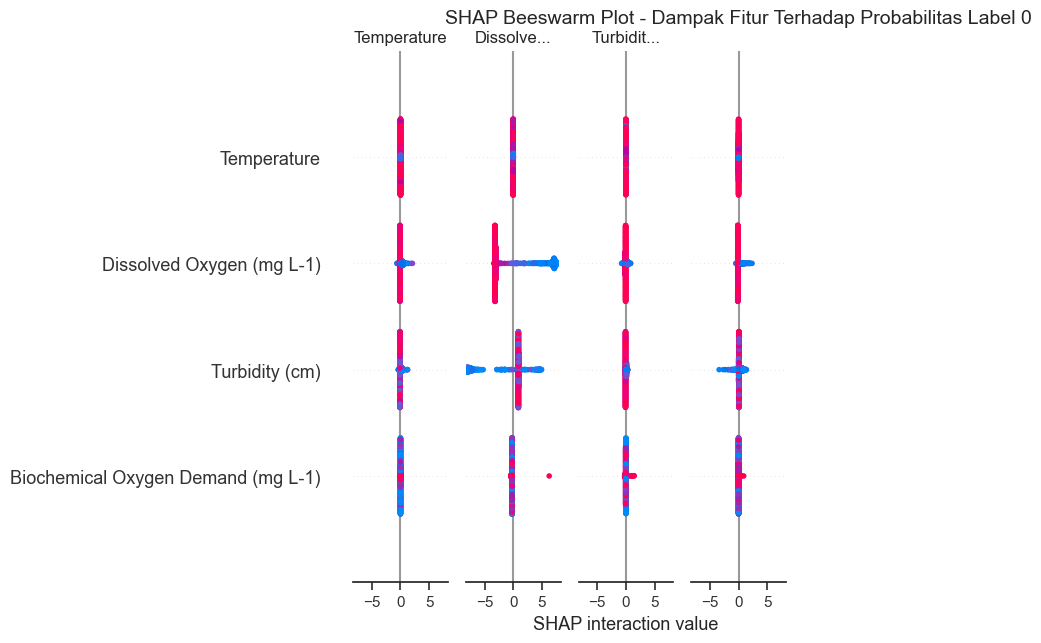

In [22]:
# ==============================================================================
# BLOK 5: EXPLAINABLE AI (SHAP ANALYSIS DARI BEST PIPELINE)
# ==============================================================================
import shap
import matplotlib.pyplot as plt

print(f"[INFO] Mengalkulasi SHAP values untuk model pemenang ({best_model_name})...")

# 1. Isolasi objek transformator dan estimator dari best_pipeline secara dinamis
scaler_step = best_pipeline.named_steps['scaler']
classifier_step = best_pipeline.named_steps['classifier']

# 2. Transformasikan data uji mentah
X_test_transformed = scaler_step.transform(X_test)
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=X_test.columns)

# 3. Eksekusi SHAP
# Catatan: TreeExplainer cocok untuk RF, DT, LGBM. Jika pemenangnya Logistic Regression, gunakan LinearExplainer
if best_model_name in ['LogisticRegression']:
    explainer = shap.LinearExplainer(classifier_step, X_test_transformed_df)
else:
    explainer = shap.TreeExplainer(classifier_step)

shap_values = explainer.shap_values(X_test_transformed_df)

# 4. Render Global Summary Plot
plt.figure(figsize=(12, 8))
# Handling perbedaan output SHAP untuk multikelas vs biner antar versi model
if isinstance(shap_values, list):
    shap.summary_plot(shap_values, X_test_transformed_df, plot_type="bar", show=False)
else:
    shap.summary_plot(shap_values, X_test_transformed_df, plot_type="bar", show=False)
plt.title(f"SHAP Global Feature Importance ({best_model_name})", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# 5. Render Local Beeswarm Plot (Dampak terhadap Kelas 0)
plt.figure(figsize=(12, 6))
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[0], X_test_transformed_df, show=False)
else:
    shap.summary_plot(shap_values, X_test_transformed_df, show=False)
plt.title(f"SHAP Beeswarm Plot - Dampak Fitur Terhadap Probabilitas Label 0", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

[INFO] Mengalkulasi SHAP values untuk model pemenang (LightGBM)...


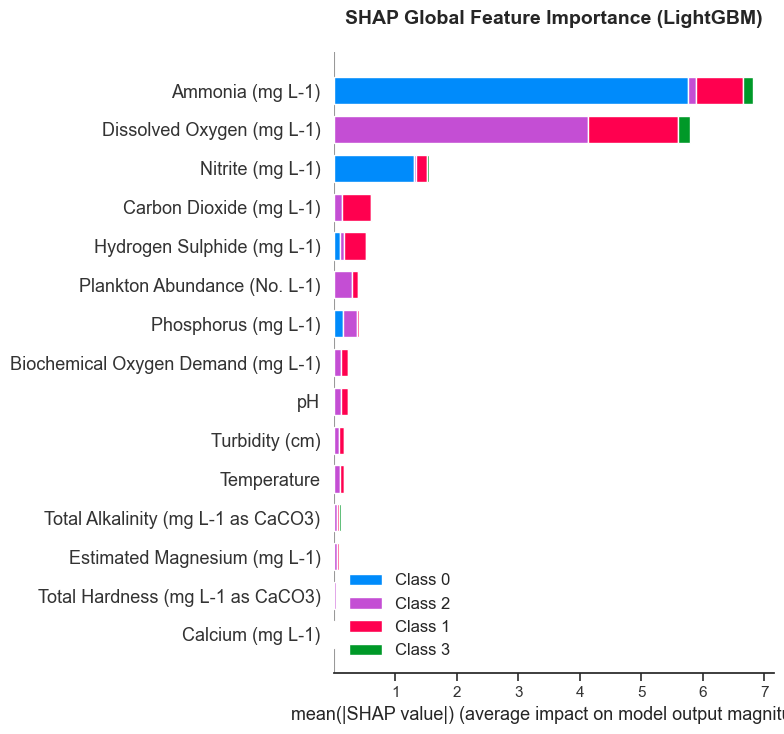

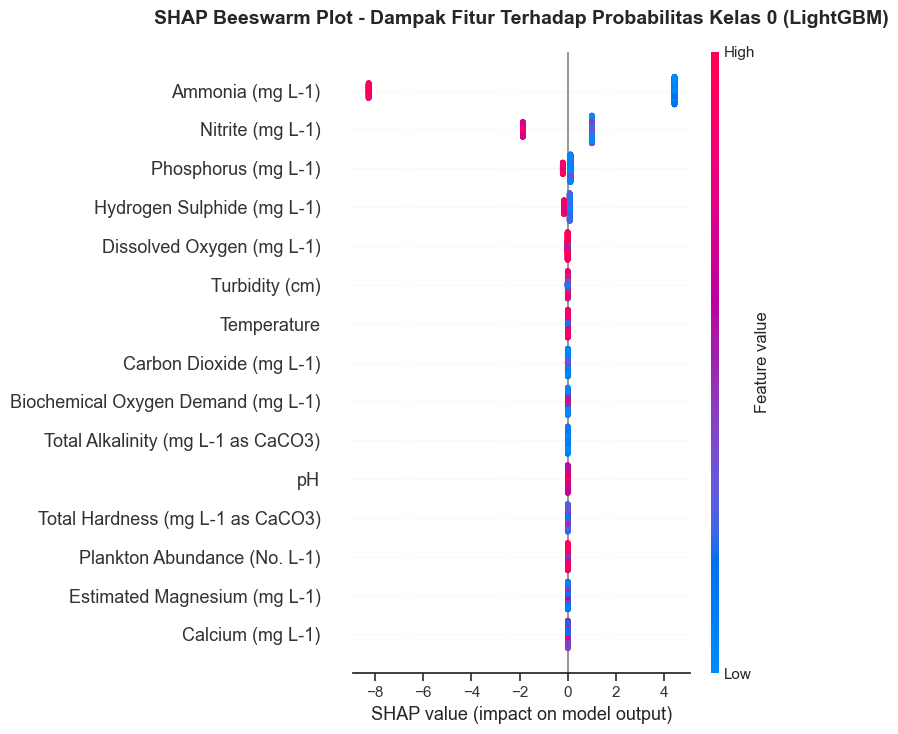

In [23]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==============================================================================
# BLOK 5: EXPLAINABLE AI (SHAP ANALYSIS DARI BEST PIPELINE)
# ==============================================================================
print(f"[INFO] Mengalkulasi SHAP values untuk model pemenang ({best_model_name})...")

# 1. Isolasi objek transformator dan estimator dari best_pipeline secara dinamis
scaler_step = best_pipeline.named_steps['scaler']
classifier_step = best_pipeline.named_steps['classifier']

# 2. Transformasikan data uji mentah ke dalam ruang dimensi scaler
X_test_transformed = scaler_step.transform(X_test)
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=X_test.columns)

# 3. Inisialisasi Explainer Berdasarkan Arsitektur Model
if best_model_name in ['LogisticRegression']:
    explainer = shap.LinearExplainer(classifier_step, X_test_transformed_df)
else:
    # Menggunakan TreeExplainer yang dioptimalkan untuk LightGBM, RandomForest, dan DecisionTree
    explainer = shap.TreeExplainer(classifier_step)

shap_values = explainer.shap_values(X_test_transformed_df)

# 4. Render Global Summary Plot (Stacked Bar Chart untuk Multikelas)
plt.figure(figsize=(12, 8))

if isinstance(shap_values, list):
    # Format RF/DT Scikit-Learn (List of Arrays)
    shap.summary_plot(shap_values, X_test_transformed_df, plot_type="bar", show=False)
elif isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
    # SINKRONISASI LIGHTGBM: Mengubah array 3D menjadi list array 2D per kelas
    # Langkah ini memaksa SHAP merender grafik batang bertumpuk (stacked bar) multi-warna
    shap_values_list = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
    shap.summary_plot(shap_values_list, X_test_transformed_df, plot_type="bar", show=False)
else:
    shap.summary_plot(shap_values, X_test_transformed_df, plot_type="bar", show=False)

plt.title(f"SHAP Global Feature Importance ({best_model_name})", fontsize=14, pad=20, fontweight='bold')
plt.tight_layout()
# Telemetri Artefak ke Server MLflow Tracking
if mlflow.active_run():
    mlflow.log_figure(plt.gcf(), "artifacts/shap_global_importance.png")
plt.show()
plt.close()

# 5. Render Local Beeswarm Plot (Dampak Spesifik Terhadap Probabilitas Kelas 0)
plt.figure(figsize=(12, 6))

if isinstance(shap_values, list):
    # Format RF/DT: Ambil indeks milik Kelas 0
    shap.summary_plot(shap_values[0], X_test_transformed_df, show=False)
elif isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
    # SINKRONISASI LIGHTGBM: Slicing dimensi ke-3 pada indeks 0 untuk mengisolasi parameter Kelas 0
    # Menghasilkan visualisasi beeswarm sebaran kontribusi fitur (merah/biru) yang valid
    shap.summary_plot(shap_values[:, :, 0], X_test_transformed_df, show=False)
else:
    shap.summary_plot(shap_values, X_test_transformed_df, show=False)

plt.title(f"SHAP Beeswarm Plot - Dampak Fitur Terhadap Probabilitas Kelas 0 ({best_model_name})", fontsize=14, pad=20, fontweight='bold')
plt.tight_layout()
# Telemetri Artefak ke Server MLflow Tracking
if mlflow.active_run():
    mlflow.log_figure(plt.gcf(), "artifacts/shap_beeswarm_class_0.png")
plt.show()
plt.close()